# $\textcolor{darkblue}{\text{Statistical Analysis of Detector Response}}$

**Iuliia Vitiugova** · University of Cambridge · Lent Term 2026

Supervisor: 
*Dr. Matt Kenzie*

$\textcolor{darkblue}{\textbf{Structure:}}$

1. Sample estimate, Least Squere fit, Boostap Mean Residuals and Relative Resolutions, Jacknife Analysis
2. Maximume Likelyhood estimate, Least Squere fit, Boostap Mean Residuals and Relative Resolutions, 1D Profiling
3. Simultaneous fit,  Boostap Mean Residuals and Relative Resolutions, 2D Profiling
4. Bootstrap analysis, Comparison of methods
5. Discussion

## $\textcolor{darkblue}{\text{The Problem}}$

Your college room mate is a Physics student having some trouble with data analysis. 

They have been asked by their supervisor to determine the performance of a photon detector in their lab. 

Your friend has diligently collected calibration samples in the lab. They have used a laser setup to produce single photons at known fixed Energies (i.e. frequencies) of $E_0$ = [20, 30, 40, 50, 60, 70, 80] GeV and recorded the measured energy, $E$, of the detector (also in GeV, although the units are irrelevant for this problem). They performed $N=1000$ measurements of the energy recorded by the detector, $E$, at each fixed point $E_0$. (Hint: we may assume the supervisor’s lab setup is so sophisticated that the energy uncertainty of the laser itself is negligible - in other words $E_0$ is known exactly with no error). 

Your friend knows, because they asked ChatGPT, that the measured energy (registered by the detection device),
$E$, will be normally distributed, $E\sim \mathcal{N}(\mu_E, \sigma^2_E)$, with mean, 

$$
\mu_E = \lambda E_0 + \Delta,
$$

and a width, $\sigma_E$, given by

$$
\left( \frac{\sigma_E}{E_0} \right)^2 = \left( \frac{a}{\sqrt{E_0}} \right)^2 + \left( \frac{b}{E_0} \right)^2 + c^2.
$$

The input data provided in `sample.csv` (which contains two columns corresponding to the laser energy, $E_0$, and the measured energy, $E$) to provide estimates of the parameters $\{ \lambda, \Delta, a, b, c\}$


In [1]:
import sys
import os

# add parent directory to path so we can import s1_sol
sys.path.insert(0, os.path.abspath('..'))

# auto-reload modules (just in case)
%load_ext autoreload
%autoreload 2

os.makedirs("figs", exist_ok=True)

---
## $\textcolor{darkblue}{\text{1) Plotting Sample Estimates}}$


### $\textcolor{darkblue}{\text{1(i) plot total sample}}$
- Get hold of your data sample, `sample.csv`, and make a plot of the measured energy, `E`, minus the true energy, `E_0`. This plot should be saved in `figs/Figure1.1.pdf`.

For each true energy $E_0$, the measured energies $E_{rec}$ are distributed as $E_{rec} ~ \sim \mathcal{N}(\mu_E, \sigma^2_E)$, with mean $\mu_E = \lambda E_0 + \Delta$, 

Total residual distribution for all energies $r = E_{rec} - E_{true}$, then 
$$r_{E_0} \sim \mathcal{N}(\mu_r(E_0), \sigma^2_r(E_0))  \sim \mathcal{N}((\lambda-1)E_0 + \Delta, \sigma^2_E(E_0)) $$
Total distribution then corresponds to a mixture of Gaussians with different parameters depending on each energy $E_0$.


Saved: Figure1.1.pdf


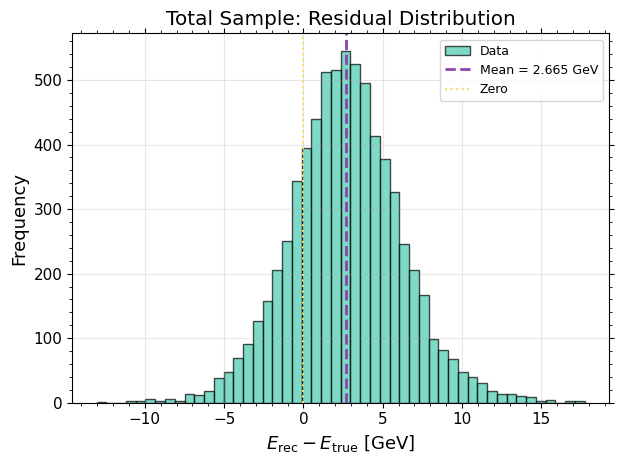

In [2]:
from s1_sol import data_loader, plotting, estimators, fitting
import matplotlib.pyplot as plt
import numpy as np

E_true_full, E_rec_full = data_loader.load_data('../sample.csv')
grouped_data = data_loader.group_by_energy(E_true_full, E_rec_full)

fig11, _ = plotting.plot_residuals(E_true_full, E_rec_full)
plotting.save_figure(fig11, 'Figure1.1.pdf')
plt.show()

---

### $\textcolor{darkblue}{\text{1(ii) overlay samples for each E0}}$
- Make a plot which shows the distribution of `E - E_0`, with the histograms for each different value of `E_0` overlaid. This plot should be saved in `figs/Figure1.2.pdf`

Saved: Figure1.2.pdf


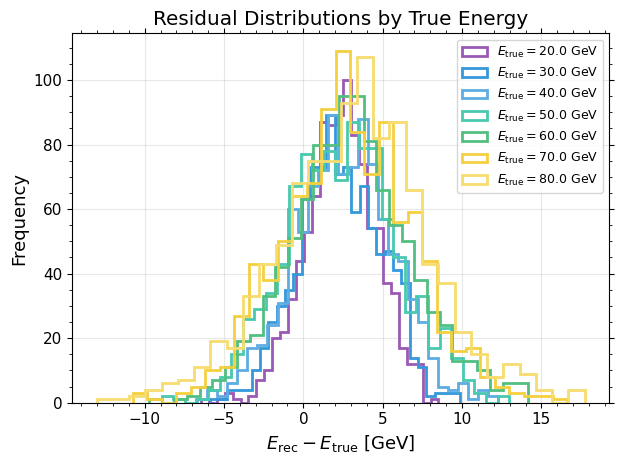

In [3]:
fig12, _ = plotting.plot_grouped_residuals(grouped_data)
plotting.save_figure(fig12, 'Figure1.2.pdf')
plt.show()

Saved: Figure1.2b.pdf


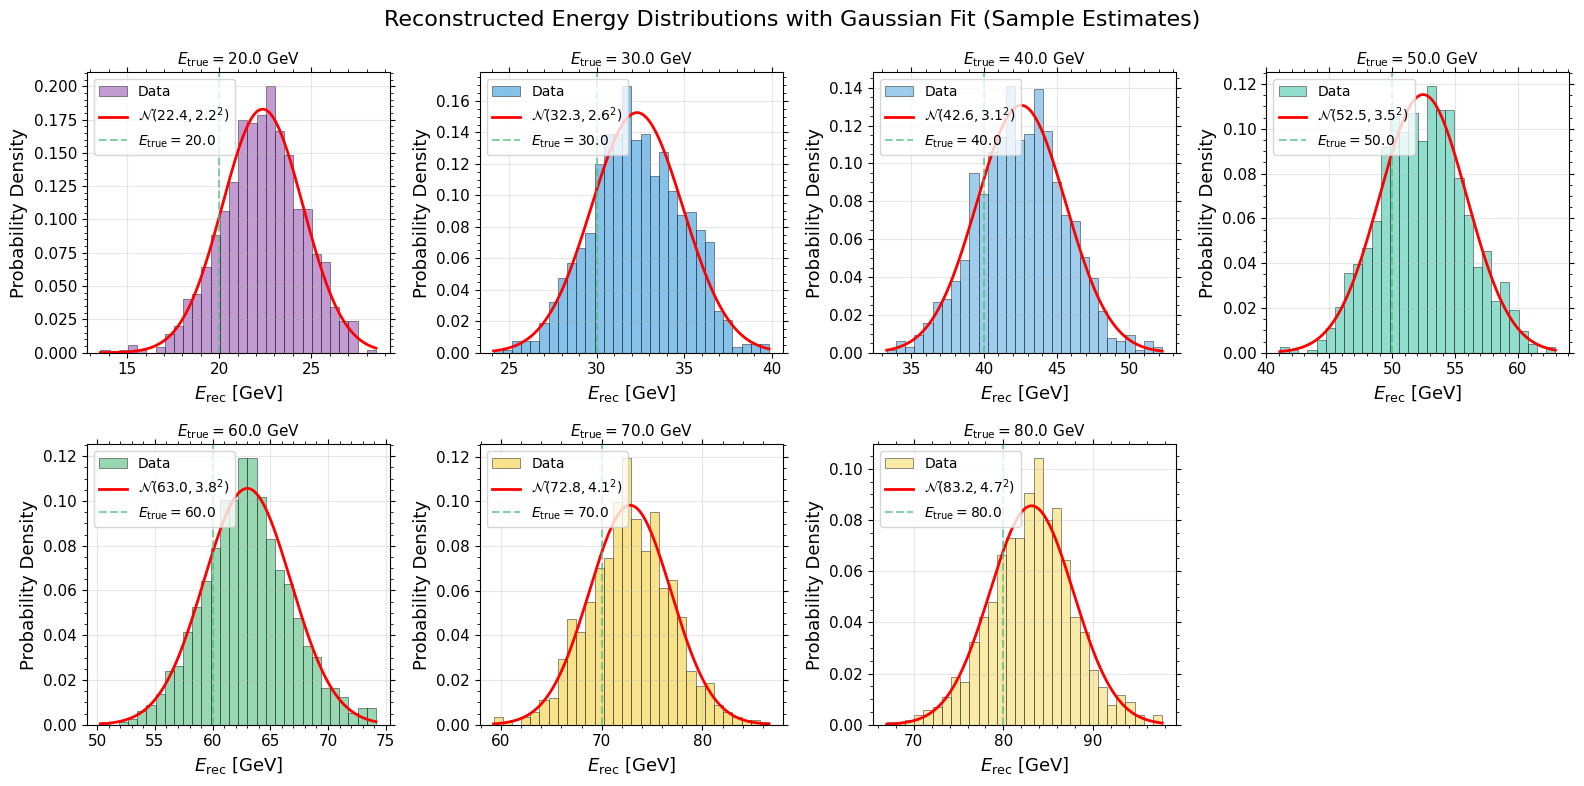

In [4]:
fig12b, _ = plotting.plot_grouped_with_gaussian(grouped_data)
plotting.save_figure(fig12b, 'Figure1.2b.pdf')
plt.show()

The plots show that the mean residual $\neq 0$,  which corresponds to a systematic bias. 

The bias of $E_{rec}$ with respect to the true energy $E_0$ is
defined as: 
$Bias(E) = \mathbb{E}[E_{rec}]-E_0,$
$$ \mathbb{E}[r] = \mathbb{E}[E_{rec} - E_0] =  \mathbb{E}[E_{rec}] - E_0 = \mu_E -E_0 
= (\lambda-1)E_0 + \Delta = Bias(E) $$

so if the estimate is unbiased $\mathbb{E}[E_{rec}] = E_0$, and consequently $\mathbb{E}[r] = 0$.

In our case, $\mathbb{E}[r] = \mu_E \neq 0 $ which is observed as a non-zero mean residual and therefore it's  $\textcolor{red}{\textbf{biased}}$.

----

### $\textcolor{darkblue}{\text{1(iii) sample estimates}}$
- Produce sample estimates of the mean, $\hat{\mu}_{\rm samp}$, and standard deviation, $\hat{\sigma}_{\rm samp}$, of $E$ at each value of $E_0$. These should be presented along with sample estimates of the error on these estimates (i.e. the standard error on the mean and the standard error on the standard deviation).
- Make two plots (sub-axes of the same figure) showing the points $\hat{\mu}_{\rm samp}$ and $\hat{\sigma}_{\rm samp}$ as a function of $E_0$. This figure should be saved to `figs/Figure1.3.pdf`

For each fixed energy $E_0$: we assume that $E_{\mathrm{rec}}$ are *i.i.d.* and samples from $\mathcal{N}(\mu_E(E_0), \sigma_E^2(E_0))$.
- The **sample mean**
$$
\hat{\mu}_{\mathrm{samp}}
= \frac{1}{N}\sum_{i=1}^{N} E_{\mathrm{rec}_i}
$$
is an unbiased estimator of this true mean $\mu_E$
$$
\mathbb{E}[\hat{\mu}_{\mathrm{samp}}]
= \frac{1}{N}\sum_{i=1}^{N}\mathbb{E}[E_{\mathrm{rec}_i}]
= \mu_E(E_0) = \lambda E_0 + \Delta
$$
As a result, all points of $\hat{\mu}_{\mathrm{samp}}$ have a linear dependency on $E_0$ (Fig.1.3.).

- The **uncertainty on the sample mean**:
$$
\mathrm{Var}[\hat{\mu}_{\mathrm{samp}}]
= \frac{\sigma_E^2(E_0)}{N},
\qquad
\delta_{\hat{\mu}}
= \frac{\hat{\sigma}_{\mathrm{samp}}}{\sqrt{N}}
$$
- The **sample standard deviation** (unbiased):
$$
\hat{\sigma}_{\mathrm{samp}}
=
\sqrt{
\frac{1}{N-1}
\sum_{i=1}^{N}
\left(E_{{rec}_i}-\hat{\mu}_{\mathrm{samp}}\right)^2
}
$$

it increase with energy, as expected from $\sigma_E(E_0) = \sqrt{a^2 E_0 + b^2 + c^2 E_0^2}$ (Fig.1.3.).
- The **uncertainty on the standard deviation** 
$$
\delta_{\hat{\sigma}}
=
\frac{\hat{\sigma}_{\mathrm{samp}}}{\sqrt{2(N-1)}}.
$$

Thus, the uncertainties 
$\delta_{\hat{\mu}} \sim 1/\sqrt{N}$ 
and 
$\delta_{\hat{\sigma}} \sim 1/\sqrt{2N}$ have the same order of magnitude, but mean values ~10 GeV, while the standard deviations ~ 1 GeV, which
explains the visibly larger error bars in the $\hat{\sigma}_{\mathrm{samp}}$ (Fig.1.3.), especially at higher energies.



Saved: Figure1.3.pdf


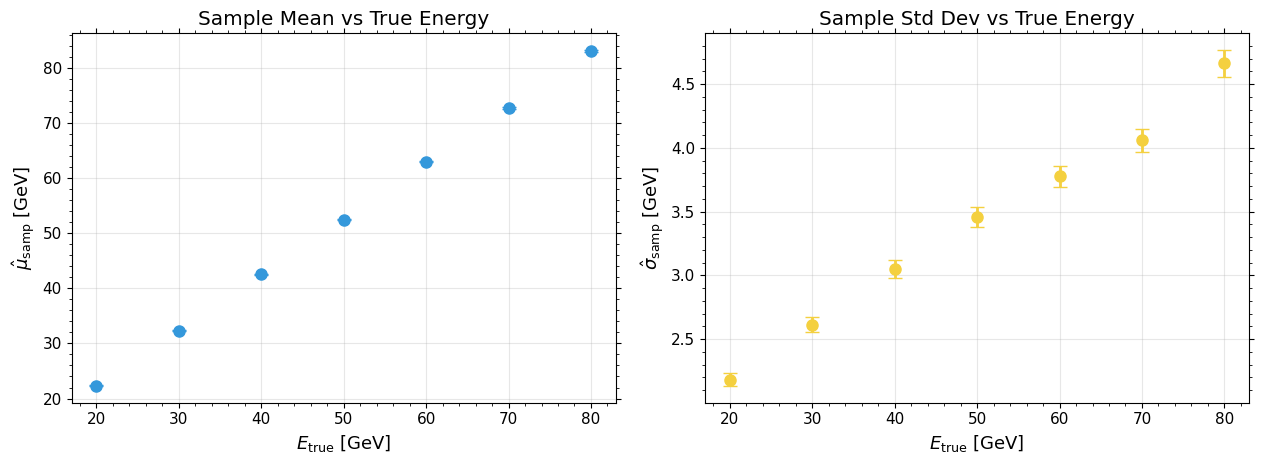

In [5]:
# mean and std estimates for each energy 
ex1_results = estimators.run_sample_estimates_analysis(grouped_data)

fig13, _ = plotting.plot_sample_estimates(
    ex1_results['E0_list'],
    ex1_results['means'], ex1_results['mean_errors'],
    ex1_results['stds'], ex1_results['std_errors'])
plotting.save_figure(fig13, 'Figure1.3.pdf')
plt.show()

---
### $\textcolor{darkblue}{\text{1(iv) fit trends}}$
- Perform a  **least squares** fit using the energy and width dependence formulas provided in the problem description to produce estimates (and estimates of the errors on those estimates) for the parameters $\lambda$, $\Delta$, $a$, $b$ and $c$. 

- The previously made plots don't have a particular sensible y-scale. Make two plots (sub-axes of the same figure) showing the points $\hat{\mu}_{\rm samp}$ and $\hat{\sigma}_{\rm samp}$ as a function of $E_0$ but this time realign the y-scale so that you plot $\hat{\mu}_{\rm samp} - E_0$ and $\hat{\sigma}_{\rm samp} / E_0$. You should also overlay the fitted curves and add error bands ($\pm 1\sigma$) to the curves by bootstrapping. This figure should be saved to `figs/Figure1.4.pdf`


By the *Central Limit Theorem (CLT)*, for large $N_i$ the sample mean is normally distributed
$$
\hat{\mu}_i
=
\frac{1}{N_i}\sum_{k=1}^{N_i} E_{\mathrm{rec}_i}^{(k)},
\quad
\hat{\mu}_i \ \overset{\mathrm{d}}{\sim}\
\mathcal{N}\!\left(\mu_i,\ \frac{\sigma_i^2}{N_i}\right)
$$
so for our model:
$$
\hat{\mu}_i {\sim}\
\mathcal{N}\!\left(
\lambda E_{0_i} + \Delta,\ \delta_{\hat{\mu}_i}^{\,2}
\right)
$$

We assume the sample means at different energies are independent, so the likelihood
for all sample means is
$$
L(\lambda,\Delta)
=
\prod_{i}
\frac{1}{\sqrt{2\pi}\,\delta_{\hat{\mu}_i}}
\exp\!\left[
-\frac{
\big(\hat{\mu}_i - (\lambda E_{0_i} + \Delta)\big)^2
}{2\,\delta_{\hat{\mu}_i}^2}
\right]
\\
\ln L(\lambda,\Delta)
=
\mathrm{C}
-
\frac{1}{2}
\sum_{i}
\frac{
\big(\hat{\mu}_i - (\lambda E_{0_i} + \Delta)\big)^2
}{\delta_{\hat{\mu}_i}^{\,2}}
$$
Maximising $\ln L$ is equivalent to minimising $-2\ln L$, and (up to
an additive constant) we can define the **least-squares** $\chi^2$ function
$$
\chi^2(\lambda,\Delta)
=
\sum_{i}
\frac{
\big(
\hat{\mu}_i
-
(\lambda E_{0_i} + \Delta)
\big)^2
}{
\delta_{\hat{\mu}_i}^{\,2}
}.
$$

This $\chi^2$ function is minimised using `iminuit` (`migrad` algorithm iteratively searches for the minimum of $\chi^2$
and returns the best parameters $(\hat{\lambda},\hat{\Delta})$)

and by *Wilks' theorem*:
$$
\chi^2(\lambda,\Delta) - \chi^2_{\min}
=
-2[\ln L(\lambda,\Delta) - \ln L_{\max}]
$$
is asymptotically distributed as a $\chi^2$ variable with $k=2$ degrees
of freedom, allowing us to construct confidence regions in the
$(\lambda,\Delta)$ plane.

For the uncertainties on the fitted parameters, we expand $\chi^2$ by *Taylor* around its
minimum:
$$
\chi^2(\theta)
\approx
\chi^2_{\min}
+
\frac{1}{2}
\sum_{j,k}
H_{jk}\,
(\theta_j - \hat{\theta}_j)
(\theta_k - \hat{\theta}_k),
\qquad
\theta = (\lambda,\Delta),
$$
where $H$ is Hessian matrix
$$
H_{jk}
=
\left.
\frac{\partial^2\chi^2}{\partial\theta_j\,\partial\theta_k}
\right|_{{\theta}=\hat{\theta}}.
$$
and covariance matrix of the fitted parameters:
$$
\mathrm{Cov}(\theta)
\approx
H^{-1}.
$$
(`iminuit` computes this `hesse` from the curvature of $\chi^2$ at the minimum)


In [6]:
# fit mean parameters
mean_minuit, mean_params, mean_errors = fitting.fit_mean_parameters(
    ex1_results['E0_list'], 
    ex1_results['means'], 
    ex1_results['mean_errors']
)
print(mean_minuit)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 10.49 (χ²/ndof = 2.1)      │              Nfcn = 50               │
│ EDM = 7.83e-16 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬────────

$\textcolor{darkblue}{\text{Least-squares for (a,b,c)}}$

For the **resolution** model:
$$
\frac{\sigma}{E_0} = \sqrt{ \frac{a^2}{E_0} +\frac{b^2}{E_0^2} + c^2},
$$
then uncertainty
$$
\delta_{\frac{\sigma}{E_{0_i}}} =
\frac{\hat{\sigma}_{\mathrm{samp}}}{E_{0_i}\sqrt{2(N-1)}}.
$$

and the final **least-squares** fit:
$$
\chi^2(a,b,c)
=
\sum_{i}
\frac{
\left(
\frac{\hat{\sigma}_{\mathrm{samp}}}{E_{0_i}}
-
\sqrt{
\frac{a^2}{E_{0_i}} + \frac{b^2}{E_{0_i}^2} + c^2}
\right)^2
}{
\delta_{\frac{\sigma}{E_{0_i}} }^{\,2}
}.
$$

In [7]:
# fit resolution parameters
res_minuit, res_params, res_errors = fitting.fit_resolution_parameters(
    ex1_results['E0_list'], 
    ex1_results['stds'], 
    ex1_results['std_errors']
)
print(res_minuit)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.383 (χ²/ndof = 0.8)      │              Nfcn = 165              │
│ EDM = 1.65e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

$\textcolor{darkblue}{\text{Non-parametric bootstrap}}$

To estimate the **uncertainty** of the fitted parameters and construct
confidence intervals, we used a **non-parametric bootstrap** method. 

- For each true energy $E_{0_i}$, energies $E_{\mathrm{rec}_i}$ were resampled with *replacement* to get bootstrap samples $E^{*(k)}_{\mathrm{rec}_i}$.
- For each bootstrap resample, we computed the sample mean and standard deviation:
$$  
\hat{\mu}^{*}_i = \frac{1}{N_i}\sum_k^{N_i} E^{*(k)}_{\mathrm{rec}_i},
\qquad
\hat{\sigma}^{*}_i
= \sqrt{
\frac{1}{N_i-1}
\sum_k^{N_i}
\bigl(E^{*(k)}_{\mathrm{rec}_i} - \hat{\mu}^{*}_i \bigr)^2
}
$$
and uncertainties:
$$
\delta^*_{\hat{\mu}_i}
=
\frac{\hat{\sigma}^{*}_i}{\sqrt{N_i}},
\qquad
\delta^*_{\frac{\sigma}{E_i}}
=
\frac{\hat{\sigma}^{*}_i}{E_{0_i}\sqrt{2(N_i-1)}}
$$
- Each bootstrap resample $\{\hat{\mu}^{*}_i,\,\hat{\sigma}^{*}_i\}$ was then fitted:
$$
\{\lambda^{*},\Delta^{*},a^{*},b^{*},c^{*}\}.
$$
- Repeating this computations $N$ times, we extracted $1\sigma$ confidence region for the fitted model.

Saved: Figure1.4.pdf


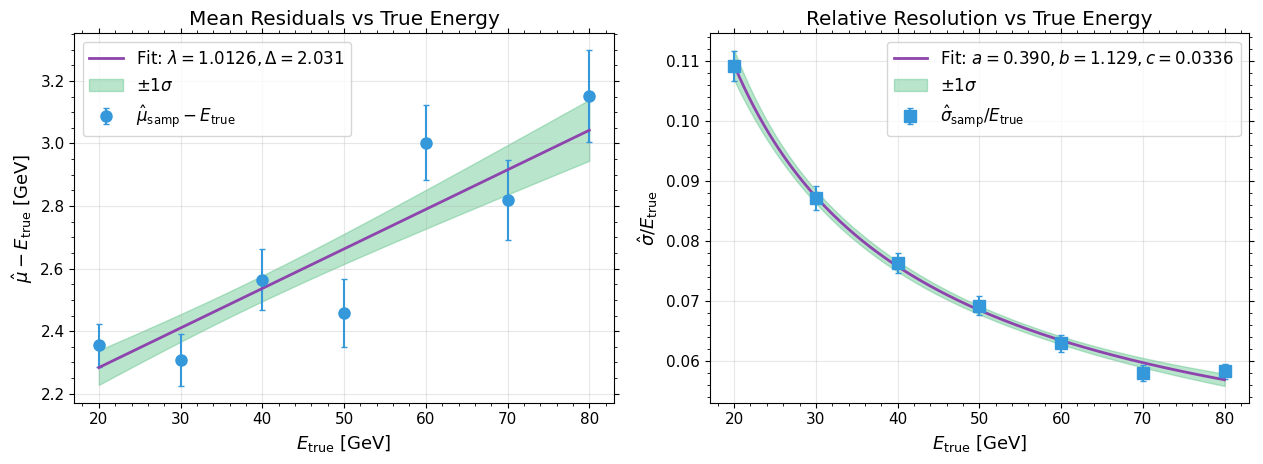

In [8]:
# bootstrap for error bands
boot_results = fitting.bootstrap_fit(grouped_data, n_bootstrap=100)

fig1_4, ax1_4 = plotting.plot_trend_fits(
    ex1_results['E0_list'],
    ex1_results['means'], ex1_results['mean_errors'],
    ex1_results['stds'], ex1_results['std_errors'],
    mean_params, res_params,
    bootstrap_results=boot_results
)
plotting.save_figure(fig1_4, 'Figure1.4.pdf')

$\textcolor{darkblue}{\text{Mean residual}}$

The data points show the residuals $r_i = \hat{\mu}_i - E_{0_i}$ with uncertainties
$
\delta_{\hat{\mu}_i} = \frac{\hat{\sigma}_{\mathrm{samp}_i}}{\sqrt{N_i}}$.

The underlying linear model
$\hat{\mu}_i = \lambda E_{0_i} + \Delta$
is fitted using a $\chi^2$ minimisation.

The bootstrap confidence region is slightly wide because the residuals have relatively large uncertainties.

$\textcolor{darkblue}{\text{Resolution}}$

The data points show the relative resolution $\hat{\sigma}_i/E_{0_i}$ with
uncertainties
$\delta_{\frac{\sigma}{E_{0_i}}} =
\frac{\hat{\sigma}_{\mathrm{samp}_i}}{E_{0_i}\sqrt{2(N_i-1)}}.$

We fit the resolution model $\frac{\sigma}{E_0} = \sqrt{\frac{a^2}{E_0}+\frac{b^2}{E_0^2}+c^2}$.

The bootstrap confidence band is much narrower here because the resolution
measurements have smaller uncertainties and the points lie closer to the fitted
curve.

---

In [9]:
# combine parameters for saving
sample_params = {**mean_params, **res_params}
sample_errors = {**mean_errors, **res_errors}
results_to_save = {
    'sample_estimates': {
        'values': sample_params,
        'errors': sample_errors 
    }}
fitting.save_results_to_json(results_to_save)

Results saved to /Users/julia/Desktop/CAM_COURSES/S1/coursework_s1/iv294/results.json


lambda: sample=1.0126, jk=1.0126, diff=-2.56e-13
Delta: sample=2.0309, jk=2.0309, diff=-5.11e-12
a: sample=0.3904, jk=0.3946, diff=+4.12e-03
b: sample=1.1294, jk=1.1064, diff=-2.30e-02
c: sample=0.0336, jk=0.0331, diff=-5.58e-04
Saved: Figure_1_Jackknife.pdf


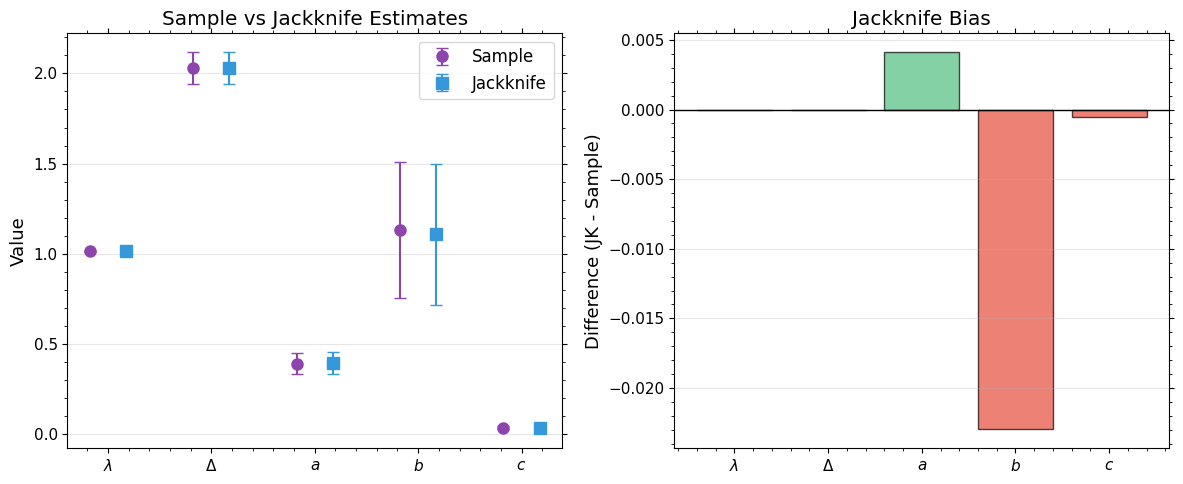

In [10]:
# jackknife analysis
jk_results = fitting.run_jackknife_analysis(grouped_data, sample_params, sample_errors)
fig_jk, _ = plotting.plot_jackknife_comparison(sample_params, sample_errors, jk_results)
plotting.save_figure(fig_jk, 'Figure_1_Jackknife.pdf')

$\textcolor{darkblue}{\text{Jackknife analysis}}$

For each parameter we compute $N$ leave-one-out estimates 
$\hat{\theta}_{(i)}$ by omitting a single value.  
From these we form the Jackknife pseudo-values
$$
\tilde{\theta}_{(i)}
=
N\hat{\theta} - (N-1)\hat{\theta}_{(i)}
$$
The Jackknife bias-corrected estimator
$$
\hat{\theta}_{\mathrm{JK}}
=
\frac{1}{N}\sum_{i=1}^{N}\tilde{\theta}_{(i)}
$$
The Jackknife variance estimate
$$
\mathrm{Var}_{\mathrm{JK}}(\hat{\theta})
=
\frac{1}{N(N-1)}
\sum_{i=1}^{N}
\left(\tilde{\theta}_{(i)} - \hat{\theta}_{\mathrm{JK}}\right)^{2}
$$

- The Jackknife corrections for $\lambda$ and $\Delta$ are $\theta_{\mathrm{JK}} - \theta_{\mathrm{sample}}
\sim \mathcal{O}(10^{-12})$ are negligible (much smaller than their uncertainties).  
This shows that *least-squares estimators in linear models are almost unbiased*.

- The Jackknife estimates of $(a,b,c)$ differ from the sample fit values by small
amounts of order $\mathcal{O}(10^{-3})$, (which is still well within their uncertainties).  The differences are larger than in the mean fit,
which is expected,  because the resolution function is nonlinear (Jackknife based on a linear approximation, for nonlinear estimators it brings a small shift, but the effect is minor).

---
## $\textcolor{darkblue}{\text{2) Individual Fits}}$

### $\textcolor{darkblue}{\text{2(i) normal fits}}$
- Now instead of sample estimates for the mean and width, perform and **unbinned maximum likelihood** fit of the distribution of $E$ at each value of $E_0$ using **a normal distribution** to determine the mean, $\hat{\mu}_{\rm indiv}$, \
and width, $\hat{\sigma}_{\rm indiv}$, (as well as their errors) at each $E_0$

- Make two plots (sub-axes of the same figure). The left should show the distribution of $E-E_0$ (with the distribution at each value of $E_0$ overlaid) also overlaying the result of the normal likelihood fits. The right should show the distribution of $E - E_0$ for all values and then overlay the approproiately normalised sum of sub-distributions. This plot should be saved in `figs/Figure2.1.pdf`

$\textcolor{darkblue}{\text{Unbinned MLE fits}}$

For each $E_{0_i}$, we have $E_{\mathrm{rec}_i}^{(1)},\ldots,E_{\mathrm{rec}_i}^{(N_i)}$, which we assume to be i.i.d. and have a normal distribution $E \sim \mathcal{N}(\mu_i,\sigma_i)$. Then the probability density for a single measurement is  
$$
p(E \mid \mu_i,\sigma_i)
=
\frac{1}{\sigma_i\sqrt{2\pi}}
\exp\!\left[
-\frac{(E-\mu_i)^2}{2\sigma_i^2}
\right]
$$
and since all measurements are independent, the *likelihood* for all
$N_i$ observations:
$$
L(\mu_i,\sigma_i)
=
\prod_{k=1}^{N_i}
p(E_{\mathrm{rec}_i}^{(k)} \mid \mu_i,\sigma_i)
$$

$$\ln L(\mu_i,\sigma_i)
=
\sum_{k=1}^{N_i}
\ln p(E_{\mathrm{rec}_i}^{(k)} \mid \mu_i,\sigma_i)
=
-\,N_i \ln \sigma_i
-\,N_i \ln \sqrt{2\pi}
-
\frac{1}{2\sigma_i^2}
\sum_{k=1}^{N_i}
(E_{\mathrm{rec}_i}^{(k)} - \mu_i)^2 
$$

and with`iminuit` we minimise the *negative* likelihood:
$$
\mathrm{NLL}(\mu_i,\sigma_i)
=
N_i \ln \sigma_i
+
\frac{1}{2\sigma_i^2}
\sum_{k=1}^{N_i}
(E_{\mathrm{rec}_i}^{(k)} - \mu_i)^2
$$

The minimisation of $\mathrm{NLL}$ gives the estimates
$$
\hat{\mu}_{\mathrm{indiv}}(E_{0_i}) 
\qquad
\hat{\sigma}_{\mathrm{indiv}}(E_{0_i})
$$


Saved: Figure2.1.pdf


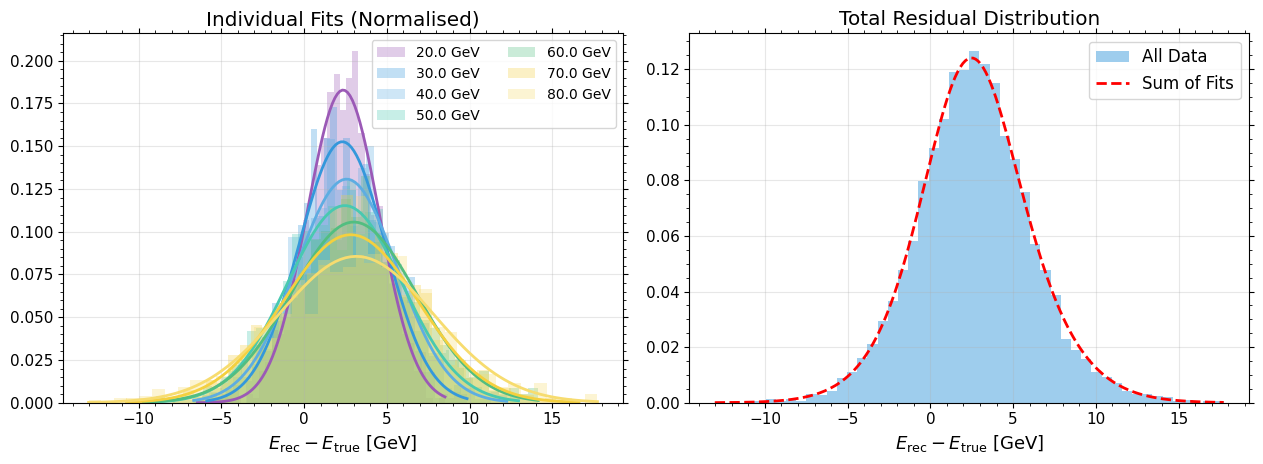

In [11]:
from s1_sol import mle_fits

# individual MLE fits for each energy (and comparison with sample estimates)
results_mle = mle_fits.run_mle_fits(grouped_data, ex1_results)

fig21, ax21 = plotting.plot_mle_histograms(grouped_data, results_mle)
plotting.save_figure(fig21, 'Figure2.1.pdf')

- The MLE for $\mu$ : 

$\frac{\partial}{\partial \mu}\ln L = -\frac{1}{2\sigma^2}\frac{\partial}{\partial \mu} \sum_{k=1}^N (E^{(k)}-\mu)^2 = -\frac{1}{2\sigma^2} \bigl(2N\mu - 2\sum_{k=1}^N E^{(k)}\bigr) = 0 $

$\hat{\mu}_{\mathrm{MLE}} = \frac{1}{N}\sum_{k=1}^N E^{(k)} $

The MLE mean is exactly the sample mean (results in the table confirm this $\Delta\mu \sim 0$).

- The MLE for $\sigma^2$:

$\frac{\partial}{\partial \sigma}\ln L = -\frac{N}{\sigma} + \frac{1}{\sigma^3} \sum_{k=1}^N (E^{(k)}-\mu)^2 = 0 $

$\hat{\sigma}^2_{\mathrm{MLE}} =
\frac{1}{N}\sum_{k=1}^N (E^{(k)}-\mu)^2
$, which is $\hat{\sigma}^2_{\mathrm{MLE}} \approx \frac{N-1}{N}\,s^2$

the MLE variance is slightly smaller than the unbiased sample
variance ($\Delta\sigma \sim -0.002$)



- The fitted Gaussians are close to the histograms which means that the *normal model is a quite good fit for the data.* (Fig.2.1)

---
### $\textcolor{darkblue}{\text{2(ii) fit trends}}$
- Perform a **least squares fit** using the energy and width dependence formulas provided in the problem description (at the top of this notebook) to produce estimates (and estimates of the errors on those estimates) for the parameters $\lambda$, $\Delta$, $a$, $b$ and $c$. Be sure to save these determinations for later or write them directly to the `results.json` file.

- Make two plots (sub-axes of the same figure) showing the fitted values $\hat{\mu}_{\rm indiv} - E_0$ and $\hat{\sigma}_{\rm indiv}/E_0$ as a function of $E_0$ **as well as** the fitted curves. You should add an error band ($\pm 1\sigma$) to the curves by bootstrapping. This figure should be saved to `figs/Figure2.2.pdf`

The same idea as in 1(iv), but mean and standard deviation are estimated from MLE.
$$
\chi^2(\lambda,\Delta)
=
\sum_i
\frac{
\bigl(
\hat{\mu}_{\mathrm{indiv}_i}
-
(\lambda E_{0_i} + \Delta)
\bigr)^2
}{
\delta_{\hat{\mu}_i}^{\,2}
}
$$
$$
\chi^2(a,b,c)
=
\sum_i
\frac{
\left(
\frac{\hat{\sigma}_{\mathrm{indiv}_i}}{E_{0_i}}
-
\sqrt{
\frac{a^2}{E_{0_i}}
+
\frac{b^2}{E_{0_i}^2}
+
c^2
}
\right)^2
}{
\delta_{\frac{\hat{\sigma}_{\mathrm{indiv}_i}}{E_{0_i}}}^{
\,2
}
}
$$

In [12]:
# extract MLE results
E0_list = sorted(results_mle.keys())
means_mle = [results_mle[E0]['mu'] for E0 in E0_list]
mean_errs_mle = [results_mle[E0]['mu_err'] for E0 in E0_list]
stds_mle = [results_mle[E0]['sigma'] for E0 in E0_list]
std_errs_mle = [results_mle[E0]['sigma_err'] for E0 in E0_list]

# fit parameters on MLE results
mean_minuit_mle, mean_params_mle, mean_errors_mle = fitting.fit_mean_parameters(
    E0_list, means_mle, mean_errs_mle
)
res_minuit_mle, res_params_mle, res_errors_mle = fitting.fit_resolution_parameters(
    E0_list, stds_mle, std_errs_mle
)

print(mean_minuit_mle)
print(res_minuit_mle)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 10.5 (χ²/ndof = 2.1)       │              Nfcn = 48               │
│ EDM = 5.03e-15 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬────────

$\textcolor{darkblue}{\text{Non-parametric bootstrap}}$

Saved: Figure2.2.pdf


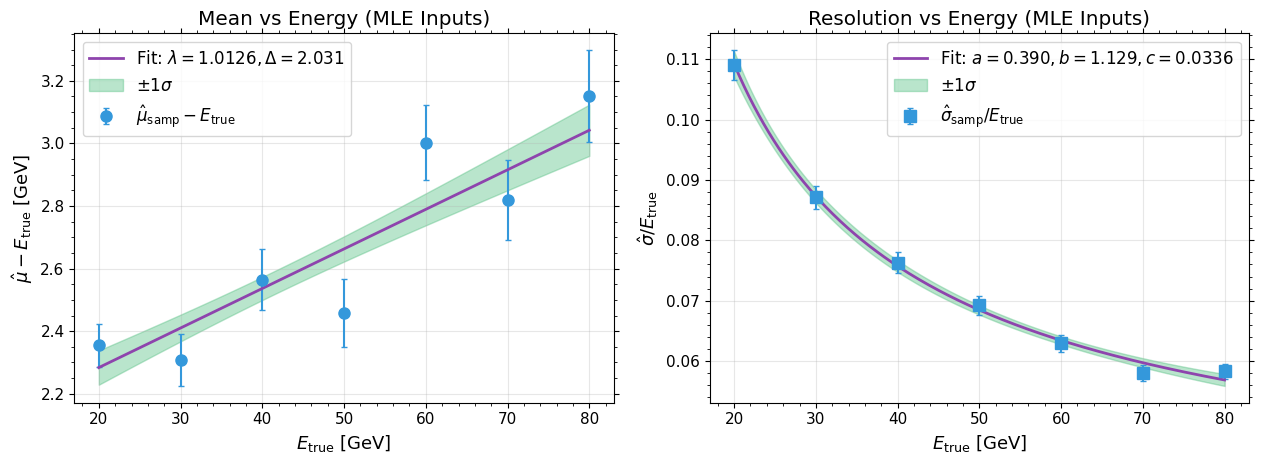

In [13]:
# bootstrap MLE parameters
boot_results_mle = fitting.bootstrap_mle_trends(grouped_data, n_bootstrap=100)

fig2_2, ax2_2 = plotting.plot_trend_fits(
    E0_list,
    means_mle, mean_errs_mle,
    stds_mle, std_errs_mle,
    mean_params_mle, res_params_mle,
    bootstrap_results=boot_results_mle)
ax2_2[0].set_title('Mean vs Energy (MLE Inputs)')
ax2_2[1].set_title('Resolution vs Energy (MLE Inputs)')
plotting.save_figure(fig2_2, 'Figure2.2.pdf')

$\textcolor{darkblue}{\text{Mean residual}}$

Plot the same figure as in Fig.1.3 ($\mu_{sample} = \mu_{MLE}$, exactly for a normal 
distribution)
 
$\textcolor{darkblue}{\text{Resolution}}$

Plot almost the same figure as in Fig.1.4 (a small correction $\sim 1/N$, which is not visible on the plot) 

$\textcolor{darkblue}{\text{Comparison MLE(individual) and sample estimates}}$

In [14]:
# compare parameters with sample estimates method
df_compare, mle_trend_params, mle_trend_errors = fitting.compare_trend_parameters(
    sample_params, sample_errors, results_mle, grouped_data)

,parameter,sample,σ(sample),mle,σ(mle),∆
0,lambda,1.012640,0.001950,1.012640,0.001949,-4.518013e-10
1,Delta,2.030900,0.086957,2.030900,0.086926,-6.694624e-09
2,a,0.390431,0.059556,0.390285,0.059372,-1.461994e-04
3,b,1.129423,0.377453,1.128535,0.376476,-8.884222e-04
4,c,0.033622,0.007911,0.033600,0.007889,-2.182873e-05


All MLE parameters agree with the sample estimates parameters within 
their $\pm 1\sigma$ uncertainties.

$\textcolor{darkblue}{\text{1D Profiling}}$

Saved: Figure2.3_mle_profiles.pdf


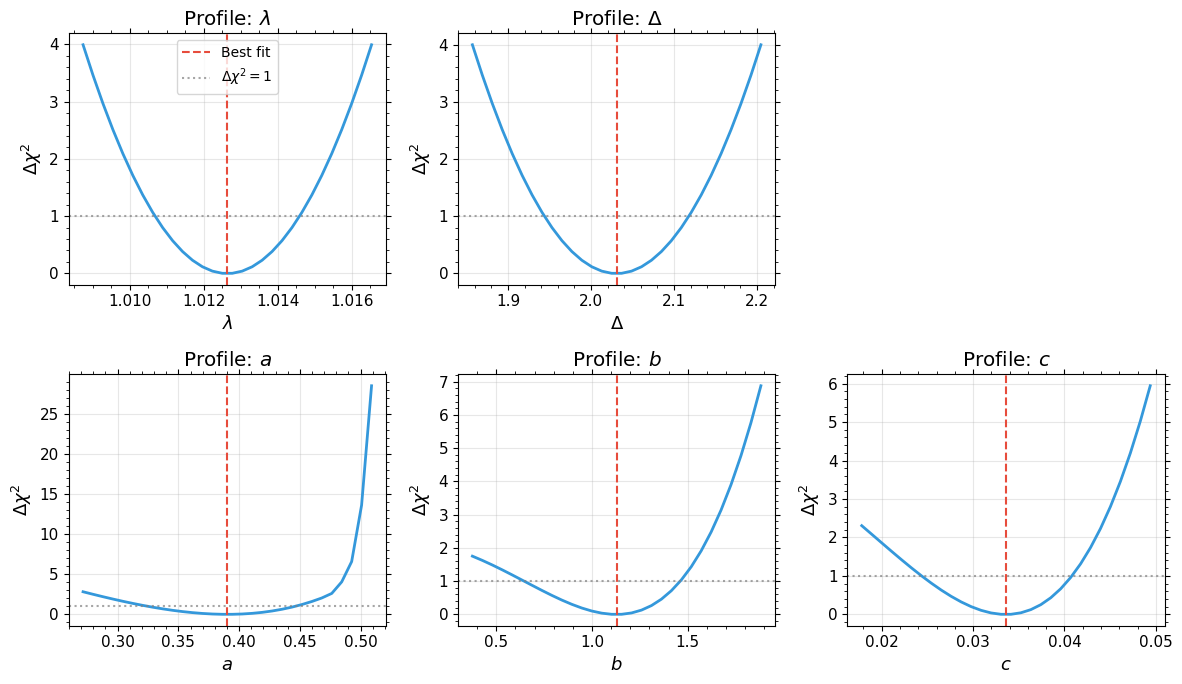

In [15]:
from s1_sol import profiling

mle_profiles = profiling.run_mle_profiles(results_mle, n_points=30)

To estimate how well our global fit parameters $(\lambda, \Delta, a, b, c)$ are
determined, we perform **profile likelihood** method.

For each parameter $\theta \in \{\lambda,\Delta,a,b,c\}$ we fix its value, re-fit all the others.
The resulting profile curves
$$
\Delta\chi^{2}(\theta)
=
\chi^{2}(\theta)-\chi^{2}_{\min}
$$ 
By Wilks’ theorem, $1\sigma$ confidence interval is $\Delta\chi^{2}=1$. (grey lines on Fig.2.3_mle_profiles)

- $\lambda$ and $\Delta$ have symmetric parabolic profiles,
showing that they are well constrained.  
- $a$, $b$, and $c$ show asymmetric shapes, due to the 
non-linear resolution model. 

---
## $\textcolor{darkblue}{\text{3.) Simultaneous Fit}}$

$\left( \frac{\sigma_E}{E} \right)^2 = \left( \frac{a}{\sqrt{E}} \right)^2 + \left( \frac{b}{E} \right)^2 + c^2$

### $\textcolor{darkblue}{\text{3(i) the simultaneous likelihood}}$
- Write down an equation for the simultaneous likelihood in which all points are fitted together, i.e. directly fitting the sample for $\lambda$, $\Delta$, $a$, $b$ and $c$
- Appropriately code this and perform an unbinned maximum likelihood fit to all $E_0$ bins simultaneously, to produce estimates (and estimates of the errors on those estimates) for the parameters $\lambda$, $\Delta$, $a$, $b$ and $c$. Be sure to save these determinations for later or write them directly to the `results.json` file.
- Make two plots (sub-axes of the same figure) showing the fitted curves for $\mu_E$ and $\sigma_E$ as a function of $E_0$. You should add an error band ($\pm 1\sigma$) to the curves by bootstrapping. You should stick to the convention of plotting $\mu_E - E_0$ and $\sigma_E / E_0$ as a function of $E_0$. This figure should be saved to `figs/Figure3.1.pdf`

### $\textcolor{darkblue}{\text{3(ii) saving the results}}$
- At this point you should have estimates of the five parameters, $\{\lambda, \Delta, a, b, c\}$, (along with their errors), using three different methods: "a sample estimate", "individual fits" and "a simultaneous fit".
- Ensure these are now saved into the `results.json` file in the correct format

$\textcolor{darkblue}{\text{Simultaneous unbinned MLE}}$

We assume each event is independent and distributed according to a normal
model whose mean and width depend on its true energy $E_{0_i}$:
$$
\mu_i = \lambda E_{0_i} + \Delta,
\qquad
\sigma_i^2 = a^2 E_{0_i} + b^2 + c^2 E_{0_i}^2.
$$

The likelihood for all $N$ events is
$$
L(\lambda,\Delta,a,b,c)
=
\prod_{i=1}^N
\frac{1}{\sqrt{2\pi}\,\sigma_i}
\exp\!\left[
-\frac{(E_{\mathrm{rec}_i} - \mu_i)^2}{2\sigma_i^2}
\right]
$$

$$
\mathrm{NLL}(\lambda,\Delta,a,b,c)
=
\sum_{i=1}^{N}
\left[
\ln\sigma_i
+
\frac{1}{2}
\frac{(E_{\mathrm{rec}_i}-\mu_i)^2}{\sigma_i^2}
\right]
$$

In [16]:
from s1_sol import simultaneous_fit

all_E_true, all_E_rec = data_loader.prepare_full_arrays(grouped_data)

# simultaneous fit
sim_minuit, sim_params, sim_errors = simultaneous_fit.run_simultaneous_fit(
    all_E_true, all_E_rec)
print(sim_minuit)

simultaneous_fit_results = {
    'simultaneous_fit': {
        'values': sim_params,
        'errors': sim_errors
    }}
fitting.save_results_to_json(simultaneous_fit_results)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.187e+04                  │              Nfcn = 256              │
│ EDM = 1.85e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬────────

$\textcolor{darkblue}{\text{Non-parametric bootstrap}}$

Saved: Figure3.1.pdf


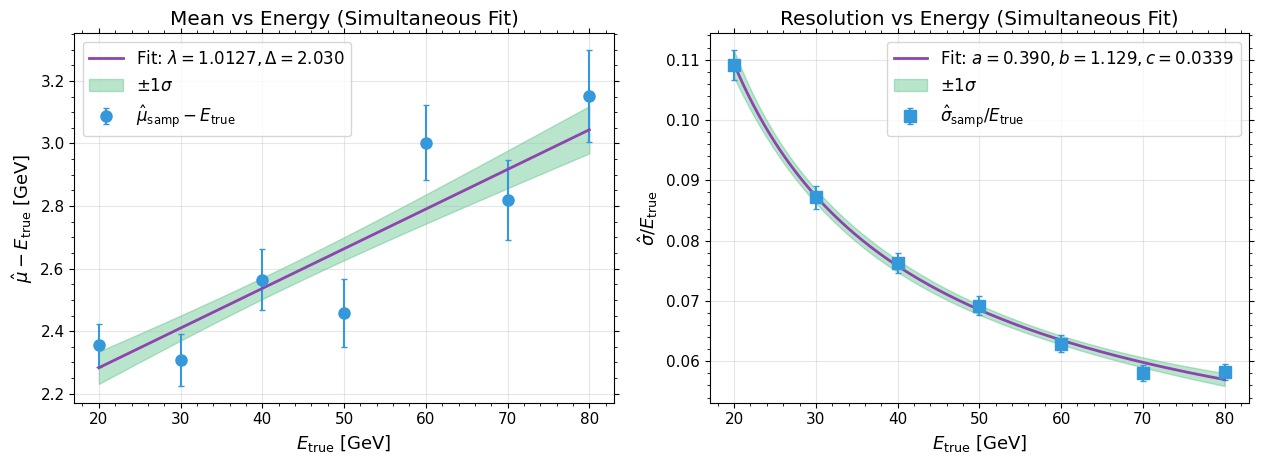

In [17]:
# bootstrap for simultaneous fit
boot_results_sim = simultaneous_fit.bootstrap_simultaneous_fit(all_E_true, all_E_rec, n_bootstrap=100)

fig3_1, ax3_1 = plotting.plot_simultaneous_fit_results(ex1_results, sim_params, boot_results_sim)
plotting.save_figure(fig3_1, 'Figure3.1.pdf')

The simultaneous unbinned likelihood uses all individual events, as a result, a Fisher information matrix $I(\theta)$ is larger/contains more information, and the variance $\operatorname{Var}(\hat\theta) \approx I(\theta)^{-1}$ is smaller, which leads to narrower bootstrap uncertainty bands.

---
### $\textcolor{darkblue}{\text{3(iii) comparing the results}}$
- Make a plot which shows the estimate and error of each parameter, labelling the different estimation types with different colours.
- The parameters may well have rather different values so you will need to think carefully about how you present this information in a sensible way.
- You should save this in a file called `figs/Figure3.2.pdf`

Saved: Figure3.2.pdf


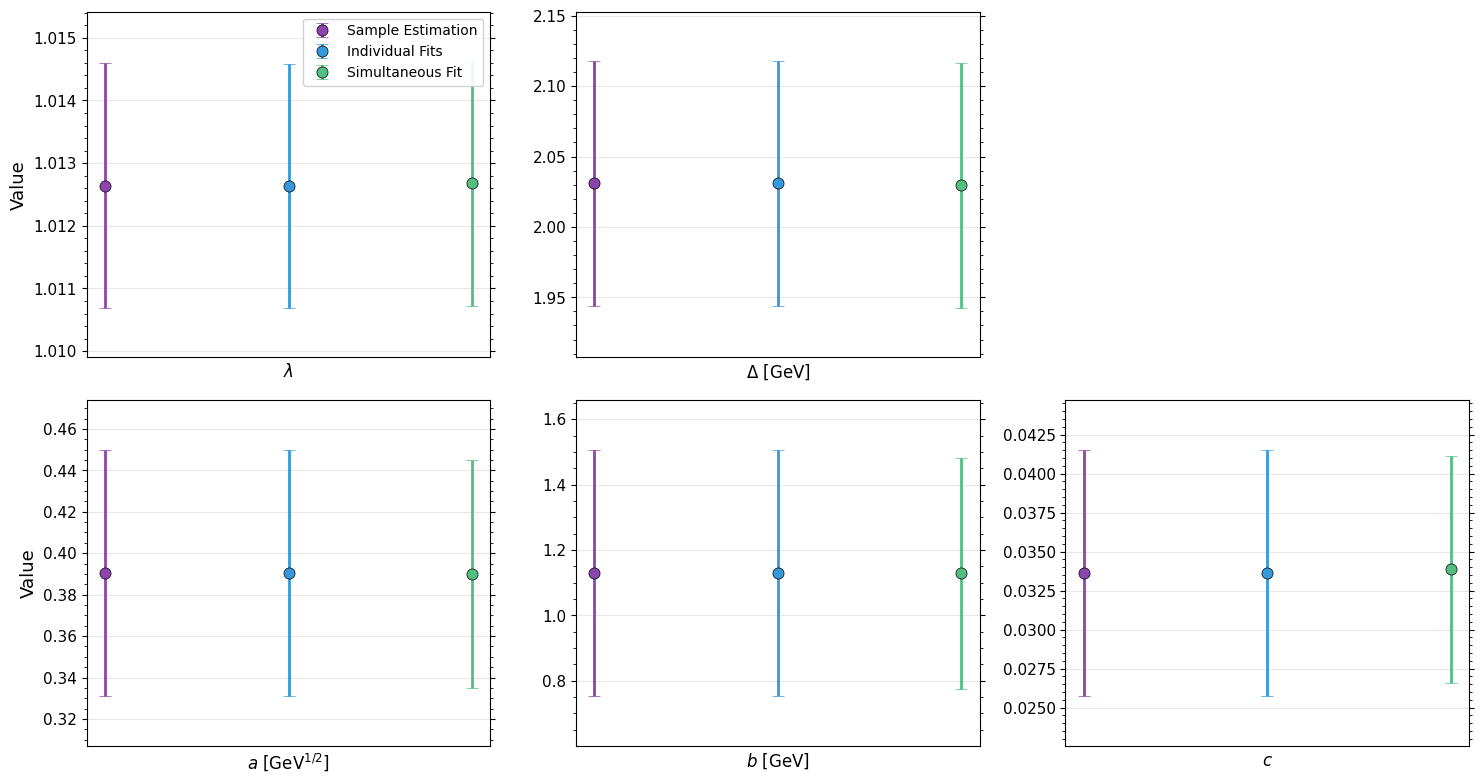

In [18]:
fig3_2, axes3_2 = plotting.plot_methods_comparison(
    sample_params, sample_errors,
    {**mean_params_mle, **res_params_mle}, {**mean_errors_mle, **res_errors_mle},
    sim_params, sim_errors)
plotting.save_figure(fig3_2, 'Figure3.2.pdf')

$\textcolor{darkblue}{\text{2D Profiling}}$

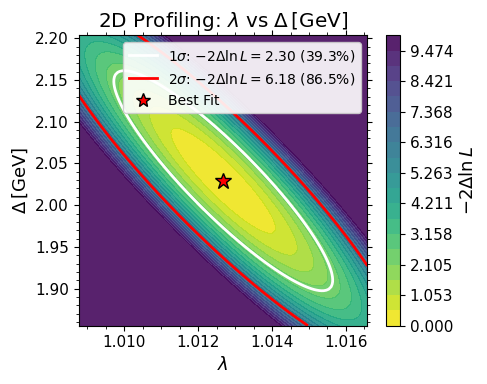

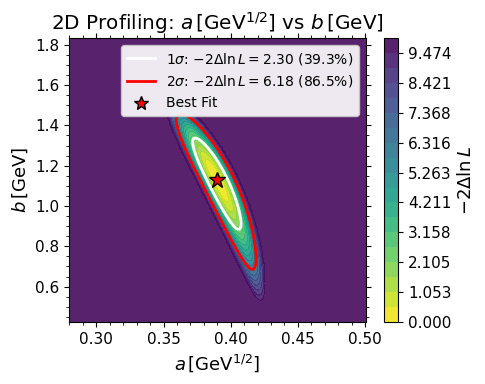

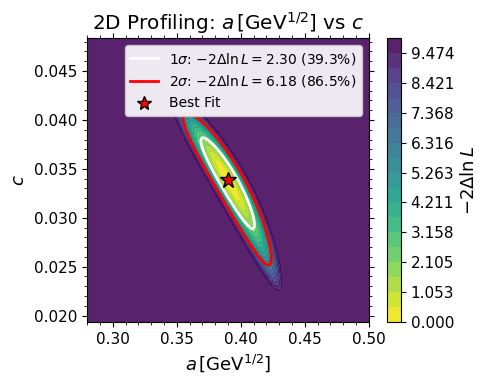

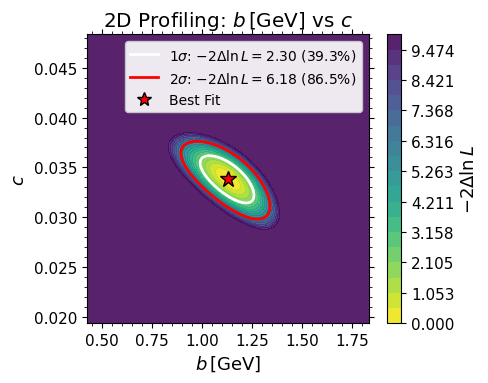

In [19]:
# λ vs Δ
fig_ld, ax_ld = plotting.plot_likelihood_grid_scan(all_E_true, all_E_rec,
                                          'lambda', 'Delta')
fig_ld.savefig('figs/Figure3.3_lambda_Delta.pdf')

# a vs b
fig_ab, ax_ab = plotting.plot_likelihood_grid_scan(all_E_true, all_E_rec,
                                          'a', 'b')
fig_ab.savefig('figs/Figure3.3_a_b.pdf')

# a vs c
fig_ac, ax_ac = plotting.plot_likelihood_grid_scan(all_E_true, all_E_rec,
                                          'a', 'c')
fig_ac.savefig('figs/Figure3.3_a_c.pdf')

# a vs c
fig_ac, ax_ac = plotting.plot_likelihood_grid_scan(all_E_true, all_E_rec,
                                          'b', 'c')
fig_ac.savefig('figs/Figure3.3_b_c.pdf')

$\textcolor{darkblue}{\text{2D Likelihood Profiling}}$

For each pair $(\theta_1,\theta_2)$ the profile likelihood
$$
-2\Delta\ln L(\theta_1,\theta_2)
=
-2\left[\ln L(\theta_1,\theta_2)-\ln L_{\max}\right]
$$
with confidence contours for 2 parameters at  
$$
1\sigma: -2\Delta\ln L = 2.30, 
\qquad
2\sigma: -2\Delta\ln L = 6.18.
$$

**$\lambda$ vs $\Delta$**

The contour exhibits a narrow, elongated ellipse, indicating a **strong correlation**
between the slope and offset of the mean energy model.
At the same time, the ellipse is tightly confined in the orthogonal direction,
showing that both parameters are **well constrained individually**.
This demonstrates that the energy scale parameters are precisely determined,
despite their strong mutual correlation.

**$a$ vs $b$**

A pronounced elongated ellipse reflects a **strong correlation**.
Compact likelihood contours indicate that only a small range of parameter values
is compatible with the data, implying that the parameters are well constrained
despite their strong correlation.

**$a$ vs $c$ and $b$ vs $c$**

The likelihood surfaces involving $c$ are visibly broader than those for $(a,b)$.
This indicates **larger uncertainties** and weaker constraints on parameter $c$,
as well as correlations between $c$ and the other resolution parameters.
Nevertheless, the contours remain closed and convex, confirming the stability
of the fit.


The 2D likelihood scans show strong correlations between several
parameters, but no degeneracies.
They explain why $(\lambda,\Delta)$ are tightly constrained despite strong
correlation, while the nonlinear resolution parameters $(a,b,c)$ exhibit larger
uncertainties.

---
## $\textcolor{darkblue}{\text{4.) Bootstrap entire sample}}$
- Run a non-parameteric bootstrap on the entire analysis using sampling with replacement (and 2500 samples). For reference on my machine this takes ~1 min)
- Produce a figure with 5 subfigures which shows histograms of the bootstrapped values with each method overlaid as a separate colour. You should save this plot in a file called `figs/Figure4.1.pdf`
- Produce a second figure which is the same in style to the plot produced in 3(iii) above this time using the bootstrapped sample to estimate the value and error. You should overlay both sets of points (i.e. the values and errors from parts 1-3 and also the bootstrapped values and errors from part 4). You should save this plot in a file called `figs/Figure4.2.pdf`

In [ ]:
ex4_results = fitting.run_full_bootstrap_analysis(all_E_true, all_E_rec, grouped_data, n_bootstrap=2500)

fig41, _ = plotting.plot_bootstrap_histograms(
    ex4_results['boot_results'], 
    ex4_results['methods'])
plotting.save_figure(fig41, 'Figure4.1.pdf')

fig42, _ = plotting.plot_parameter_comparison(
    ex4_results['methods'],
    {p: ex4_results['boot_results']['simultaneous_fit'][p] for p in ['lambda','Delta','a','b','c']})
plotting.save_figure(fig42, 'Figure4.2.pdf')

All three methods are (approximately) *unbiased* under the assumption of a
Gaussian detector response model (for each $E_0$, $E_{\mathrm{rec}} \sim \mathcal{N}(E_0, \sigma_E^2)$), 

but they differ in their efficiency $Var(\hat{\theta})$ (in the size of their uncertainties).
- As discussed, $\textcolor{green}{\textit{for a normal distribution the unbinned MLE of the mean is identical with the sample mean}}$, $\hat\mu_{\mathrm{MLE}}=\hat\mu_{sample}$, this explains why the estimates of the mean-response parameters
$(\lambda,\Delta)$ are very similar across all three methods
(Figs. 4.1 and 4.2).
	
- The resolution model is nonlinear in the parameters $(a,b,c)$, when fitting this model using per energy estimates $\hat{\sigma}_i$,
the parameters enter quadratically and under a square root, leading to strong
correlations between $(a,b,c)$. As a consequence, $\textcolor{green}{\textit{the curvature (Hessian) of the objective function depends on
the parameter values themselves}}$ , resulting in larger uncertainties compared to
the linear mean model (Figs. 4.1 and 4.2).

- The simultaneous unbinned fit maximises a single likelihood constructed from
all energies $E_0$, compare to compressing the data into per energy estimates ${(\hat{\mu}_i,\hat{\sigma}_i)}$.
Since such a compression cannot increase information, the simultaneous fit is more $\textcolor{green}{\textit{efficient and yields the smallest
uncertainties}}$, in particular for the nonlinear resolution parameters $(a,b,c)$
(Fig. 4.2).

- The bootstrap uncertainties are slightly larger than the analytic
uncertainties obtained from the curvature of the likelihood.
This is expected, since $\textcolor{green}{\textit{ Hessian uncertainties rely on a local quadratic
approximation of the likelihood}}$, whereas $\textcolor{green}{\textit{the bootstraps search the full sampling
variability of the estimator}}$. 
The effect is more visible for the nonlinear resolution parameters $(a,b,c)$,
while for the linear mean parameters $(\lambda,\Delta)$ both uncertainty
estimates agree very well (Fig. 4.2).


---
## $\textcolor{darkblue}{\text{5.) Discussion of Results}}$

$\textcolor{darkblue}{\textbf{Unbiasedness and consistency of the estimators}}$

Throughout this work we assumed that, for each fixed true energy $E_0$, the
reconstructed energies are *i.i.d.* 

$E_{\mathrm{rec}}  \sim
\mathcal{N}\bigl(\mu_E,\,\sigma_E^2\bigr)$ with $\mu_E = \lambda E_0 + \Delta$ and $\sigma_E^2 = a^2 E_0 + b^2 + c^2 E_0^2$

Under this model, the **unbinned maximum likelihood estimator of the mean
equals the sample mean**:
$ \hat{\mu}_{\mathrm{MLE}} = \arg\max_{\mu}\sum_{k}\ln p(E_k\mid\mu,\sigma) = \frac{1}{N}\sum_{k=1}^N E_k = \hat{\mu}_{\mathrm{samp}}$.

It satisfies $\mathbb{E}[\hat{\mu}_{\mathrm{samp}}] = \mu_E,$
$\mathrm{Var}(\hat{\mu}_{\mathrm{samp}})=\frac{\sigma_E^2}{N}.$

Therefore, the estimators of the linear trend parameters $(\lambda,\Delta)$
obtained from all three methods are **approximately unbiased** under the assumed normal model.

Moreover,
$$
\hat{\mu}_{\mathrm{samp}}
\xrightarrow[N\to\infty]{\mathbb{P}}
\mu_E
$$
which is **consistent** with the expected asymptotic behavior of the least-squares estimators of $(\lambda,\Delta)$.

$\textcolor{darkblue}{\textbf{Information and variance of the estimators}}$

The differences between the three methods in
**information retained in the likelihood.** 

For a parameter $\theta$, the *variance bound* gives relationship between the variance of an estimator and information
$$
\mathrm{Var}(\hat{\theta})
\geq
I(\theta)^{-1}  = 
-\left(\mathbb{E}\!\left[
\frac{\partial^2\ln L}{\partial\theta^2}
\right]\right)^{-1}
$$

In sample estimates and individual fits, the full
data is divided into per energy statistics $(\hat{\mu}_i,\hat{\sigma}_i)$, 
and parameters are then obtained from a $\chi^2$ fit by each energy.  It relies on an approximation to the full likelihood and
does not fully capture the correlations between measurements at different energies.
As a result, the information is reduced and leads to **larger variances of the estimators**.

In contrast, the simultaneous fit maximises a single unbinned likelihood
$$
\ln L(\theta)
=
\sum_{j=1}^{N}
\ln p(E_{\mathrm{rec}_j}\mid E_{0_j},\theta)
$$

which uses all events simultaneously and contains more information about parameters within different energies, which yield **smaller variances** among the methods.

$\textcolor{darkblue}{\textbf{Linear and nonlinear parameter dependence}}$

The mean model
$$
\mu_E=\lambda E_0+\Delta
$$
is linear in the parameters, this $\chi^2$ is **a quadratic function** of the parameters (parabola with a clear minimum, symmetric plofiles).
$$
\chi^2(\theta)
\approx
\chi^2_{\min}
+
(\theta-\hat{\theta})^{T} H (\theta-\hat{\theta})
\qquad
H=\nabla^2\chi^2
$$
The resolution model
$$
\frac{\sigma_E}{E_0}
=
\sqrt{\frac{a^2}{E_0}+\frac{b^2}{E_0^2}+c^2}
$$
is nonlinear in $(a,b,c)$.
The parameters enter quadratically and under a square root, leading to strong correlations in the Hessian $H(\theta)$ (shifted, asymmetric profiles).
This explains the **larger and more asymmetric uncertainties**
observed for $(a,b,c)$ in all fits.

$\textcolor{darkblue}{\textbf{Bootstrap and Hessian uncertainties}}$

Hessian uncertainties rely on a quadratic approximation of the
likelihood around its maximum. In contrast, the non-parametric bootstrap estimates the sampling distribution of the estimator directly by resampling the data
$$
\hat{\theta}^{*(b)} = \hat{\theta}(X^{*(b)}),
\qquad
\mathrm{Var}_{\mathrm{b}}(\hat{\theta})
=
\frac{1}{B-1}
\sum_{b=1}^{B}
\bigl(\hat{\theta}^{*(b)}-\bar{\theta}^{*}\bigr)^2 
$$

The Hessian uncertainties are obtained from the best fitted point and therefore describe the local
sensitivity of the estimator for fixed data.
Meanwhile, the bootstrap uncertainties calculate the empirical variability of
the fitted parameters under repeated resampling of the data, therefore
propagates the entire estimation.
As a result, bootstrap uncertainties are slightly larger, especially
for nonlinear parameters $(a,b,c)$.

$\textcolor{darkblue}{\textbf{Summary}}$

All three methods have almost unbiased and asymptotically consistent estimators under the assumed
normal model. 

The observed hierarchy of uncertainties follows:

(i) the amount of information retained by each method

(ii) the linear or nonlinear dependence of the model on its parameters

(iii) the difference between local (Hessian) and global (bootstrap) uncertainty
estimation.

**<font color="darkred">*Musical interlude...*</font>**

[Peer Gynt, Edvard Grieg](https://youtu.be/pgRrY1d-O7A?si=A3CV4lT68uRO080m)
